# W02 Practical Notebook — Uncertainty, Probability and Bayes' Rule

**Module:** Principles and Applications of Artificial Intelligence and Machine Learning  
**Week:** W02  
**Duration:** 4 hours  
**MLOs:** MLO1, MLO2  

## Learning objectives

By the end of this practical, you should be able to:

1. Explain why uncertainty is important in Artificial Intelligence.
2. Represent uncertainty using probability.
3. Calculate complements, joint probabilities and conditional probabilities.
4. Explain prior probability, likelihood, evidence and posterior probability.
5. Apply Bayes' Rule to simple AI problems.
6. Use Python to simulate uncertain events and visualise probability.
7. Build a very simple agent that updates its belief using evidence.

> The Python in this notebook is intentionally simple. The emphasis is on understanding the AI concepts.

## 0. Libraries

We need only three common libraries:

- `random` for simple simulations
- `numpy` for numerical experiments
- `matplotlib` for graphs

In [38]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Part 1 — What is uncertainty?

AI systems rarely have complete knowledge.

Examples:

- Will it rain tomorrow?
- Is this email spam?
- Does this medical image contain an abnormality?
- Is this transaction fraudulent?
- Is the object detected by a camera really a pedestrian?

Instead of always saying **True** or **False**, an AI system can represent uncertainty using a probability between 0 and 1.

- Probability = 0 → impossible
- Probability = 1 → certain
- Probability between 0 and 1 → uncertain

## Example 1 — Probability of rain

Suppose a weather system estimates a 70% probability of rain.

In [39]:
p_rain = 0.70
p_no_rain = 1 - p_rain

print("P(Rain) =", p_rain)
print("P(No Rain) =", p_no_rain)

P(Rain) = 0.7
P(No Rain) = 0.30000000000000004


### Graph 1 — Visualising uncertainty

The two possible outcomes together must have probability 1.

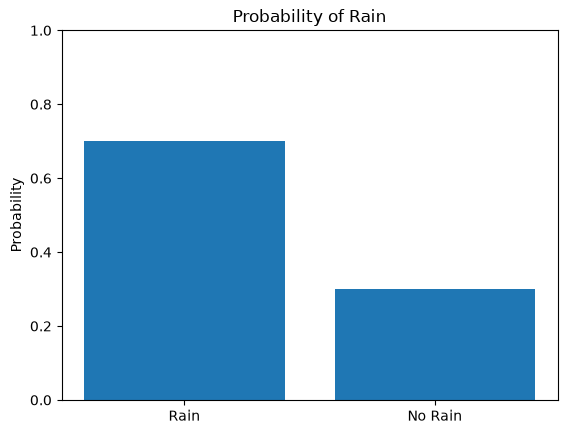

In [40]:
plt.bar(["Rain", "No Rain"], [p_rain, p_no_rain])
plt.ylabel("Probability")
plt.title("Probability of Rain")
plt.ylim(0, 1)
plt.show()

## Example 2 — Turning uncertainty into a decision

Probability describes uncertainty. A **decision rule** determines what an agent does about it.

Here we use a very simple threshold of 0.5.

In [4]:
p_rain = 0.70

if p_rain > 0.5:
    action = "Take an umbrella"
else:
    action = "No umbrella needed"

print("Probability of rain:", p_rain)
print("Agent decision:", action)

Probability of rain: 0.7
Agent decision: Take an umbrella


### Student experiment

Change `p_rain` to:

- 0.20
- 0.49
- 0.51
- 0.90

Observe when the decision changes.

# Part 2 — Simulating probability

A probability of 0.70 does **not** mean that rain must occur.

It means that over many comparable trials, rain is expected approximately 70% of the time.

## Example 3 — Simulate one uncertain event

In [41]:
p_rain = 0.70

random_number = random.random()

print("Random number:", random_number)

if random_number < p_rain:
    print("Result: Rain")
else:
    print("Result: No Rain")

Random number: 0.6076095412554097
Result: Rain


Run the previous cell several times.

The result can change even though the probability remains 0.70. This is the nature of an uncertain event.

## Example 4 — Simulate 100 days

In [42]:
p_rain = 0.70
rain_count = 0

for day in range(100):
    if random.random() < p_rain:
        rain_count += 1

no_rain_count = 100 - rain_count

print("Rainy days:", rain_count)
print("Non-rainy days:", no_rain_count)
print("Estimated probability:", rain_count / 100)

Rainy days: 72
Non-rainy days: 28
Estimated probability: 0.72


### Graph 2 — Results of 100 simulated days

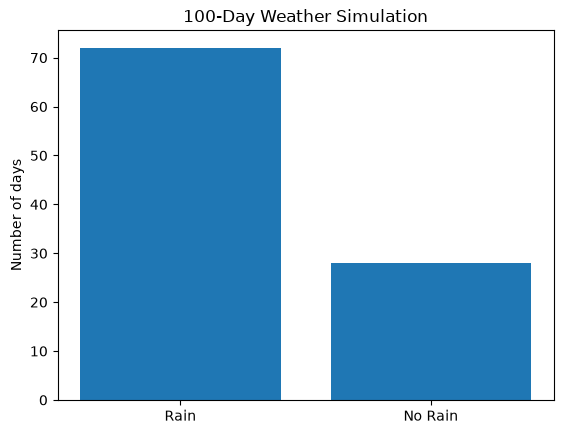

In [43]:
plt.bar(["Rain", "No Rain"], [rain_count, no_rain_count])
plt.ylabel("Number of days")
plt.title("100-Day Weather Simulation")
plt.show()

## Example 5 — Does experimental probability approach theoretical probability?

Now increase the number of trials.

We will compare:

**Theoretical probability = 0.70**

with the probability estimated from simulation.

In [44]:
p_rain = 0.70

trial_sizes = [10, 50, 100, 500, 1000, 5000]
estimated_probabilities = []

for trials in trial_sizes:
    rain = 0

    for i in range(trials):
        if random.random() < p_rain:
            rain += 1

    estimated_probabilities.append(rain / trials)

print(estimated_probabilities)

[0.8, 0.8, 0.66, 0.676, 0.71, 0.709]


### Graph 3 — Convergence towards the true probability

As the number of trials increases, the estimated probability generally becomes more stable around 0.70.

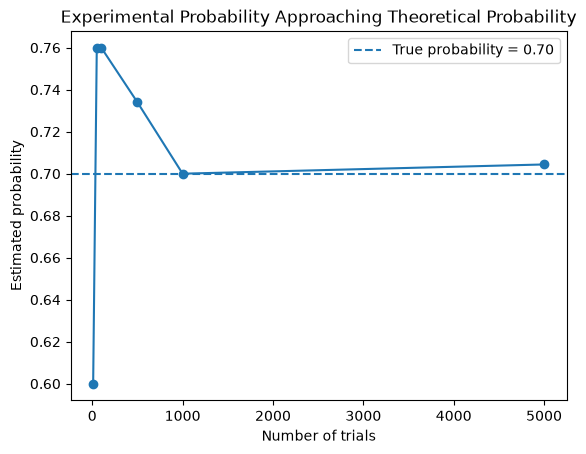

In [9]:
plt.plot(trial_sizes, estimated_probabilities, marker="o")
plt.axhline(0.70, linestyle="--", label="True probability = 0.70")
plt.xlabel("Number of trials")
plt.ylabel("Estimated probability")
plt.title("Experimental Probability Approaching Theoretical Probability")
plt.legend()
plt.show()

# Part 3 — Probability from observed data

Probability can also be estimated from data.

Suppose we recorded weather for ten days.

In [10]:
weather = [
    "Rain", "Rain", "Sunny", "Rain", "Sunny",
    "Rain", "Rain", "Sunny", "Rain", "Sunny"
]

rain_count = weather.count("Rain")
total_days = len(weather)

p_rain = rain_count / total_days

print("Rainy days:", rain_count)
print("Total days:", total_days)
print("P(Rain) =", p_rain)

Rainy days: 6
Total days: 10
P(Rain) = 0.6


### Graph 4 — Observed weather data

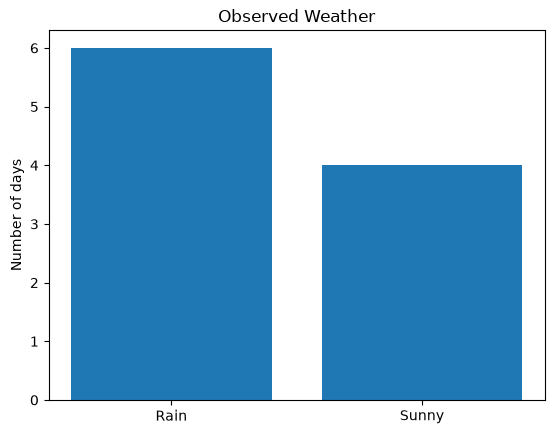

In [11]:
sunny_count = weather.count("Sunny")

plt.bar(["Rain", "Sunny"], [rain_count, sunny_count])
plt.ylabel("Number of days")
plt.title("Observed Weather")
plt.show()

# Part 4 — Complement probability

If an event has probability `P(A)`, then:

**P(not A) = 1 - P(A)**

If P(Rain) = 0.60, then P(No Rain) = 0.40.

In [12]:
p_rain = 0.60
p_no_rain = 1 - p_rain

print("P(Rain) =", p_rain)
print("P(No Rain) =", p_no_rain)
print("Total =", p_rain + p_no_rain)

P(Rain) = 0.6
P(No Rain) = 0.4
Total = 1.0


# Part 5 — Joint probability

Sometimes we are interested in two events occurring together.

Suppose:

- P(Rain) = 0.60
- P(Traffic | Rain) = 0.80

Then the probability of rain **and** traffic is:

In [13]:
p_rain = 0.60
p_traffic_given_rain = 0.80

p_rain_and_traffic = p_rain * p_traffic_given_rain

print("P(Rain and Traffic) =", p_rain_and_traffic)

P(Rain and Traffic) = 0.48


### Graph 5 — Following the probability path

Out of 100 comparable days, approximately:

- 60 are expected to be rainy.
- 80% of those rainy days are expected to have traffic.
- Therefore about 48 out of 100 days are expected to have both rain and traffic.

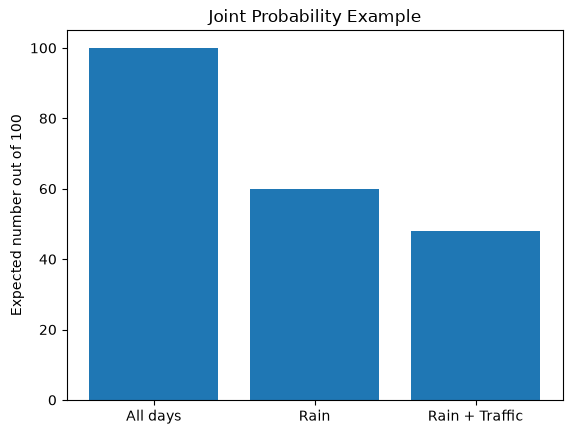

In [14]:
values = [100, 60, 48]
labels = ["All days", "Rain", "Rain + Traffic"]

plt.bar(labels, values)
plt.ylabel("Expected number out of 100")
plt.title("Joint Probability Example")
plt.show()

# Part 6 — Conditional probability

Conditional probability asks:

> What is the probability of event A **given that** event B has occurred?

For example:

**P(Traffic | Rain)**

means:

> Probability of traffic given that we know it is raining.

In [15]:
rainy_days = 100
rainy_days_with_traffic = 80

p_traffic_given_rain = rainy_days_with_traffic / rainy_days

print("P(Traffic | Rain) =", p_traffic_given_rain)

P(Traffic | Rain) = 0.8


## Example 6 — Conditional probability from a small dataset

Suppose we recorded whether it rained and whether traffic was heavy.

In [16]:
rain =    [1, 1, 0, 1, 0, 1, 1, 0, 1, 0]
traffic = [1, 1, 0, 1, 1, 0, 1, 0, 1, 0]

rainy_days = sum(rain)

rain_and_traffic = 0

for i in range(len(rain)):
    if rain[i] == 1 and traffic[i] == 1:
        rain_and_traffic += 1

p_traffic_given_rain = rain_and_traffic / rainy_days

print("Rainy days:", rainy_days)
print("Rainy days with traffic:", rain_and_traffic)
print("P(Traffic | Rain) =", p_traffic_given_rain)

Rainy days: 6
Rainy days with traffic: 5
P(Traffic | Rain) = 0.8333333333333334


# Part 7 — Bayes' Rule

Bayes' Rule is one of the most important tools for reasoning under uncertainty.

It allows us to **update a belief after receiving new evidence**.

\[
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
\]

The main ideas are:

- **Prior** — belief before seeing the evidence
- **Likelihood** — probability of seeing the evidence if the hypothesis is true
- **Evidence** — overall probability of observing the evidence
- **Posterior** — updated belief after seeing the evidence

A simple way to remember Bayes:

**Prior belief + New evidence → Updated belief**

# Part 8 — Medical test example

Suppose:

- 1% of people have a disease.
- The test is positive for 90% of people who have the disease.
- The test is also positive for 5% of healthy people.

A person tests positive.

**Question:** What is the probability that the person actually has the disease?

It is tempting to answer 90%, but that ignores how rare the disease is.

## Step 1 — Define the probabilities

In [17]:
p_disease = 0.01
p_no_disease = 1 - p_disease

p_positive_given_disease = 0.90
p_positive_given_no_disease = 0.05

print("P(Disease) =", p_disease)
print("P(No Disease) =", p_no_disease)

P(Disease) = 0.01
P(No Disease) = 0.99


### Graph 6 — Prior probability

Before seeing the test result, disease is rare.

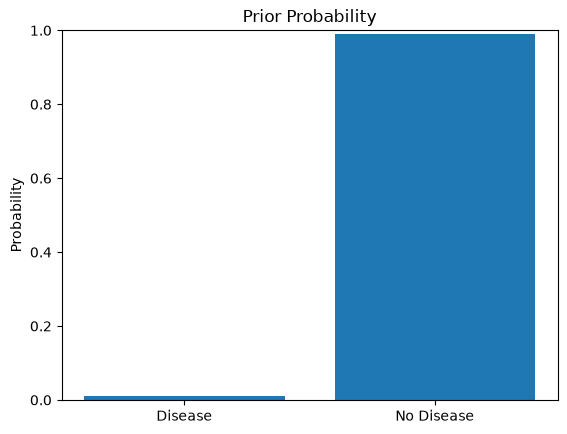

In [18]:
plt.bar(["Disease", "No Disease"], [p_disease, p_no_disease])
plt.ylabel("Probability")
plt.title("Prior Probability")
plt.ylim(0, 1)
plt.show()

## Step 2 — Calculate the probability of a positive test

A positive result can come from:

1. A person who has the disease and tests positive.
2. A healthy person who receives a false positive.

In [19]:
p_positive = (
    p_positive_given_disease * p_disease
    +
    p_positive_given_no_disease * p_no_disease
)

print("P(Positive) =", p_positive)

P(Positive) = 0.0585


## Step 3 — Apply Bayes' Rule

In [20]:
p_disease_given_positive = (
    p_positive_given_disease * p_disease
) / p_positive

print("P(Disease | Positive) =", p_disease_given_positive)
print("Percentage =", round(p_disease_given_positive * 100, 2), "%")

P(Disease | Positive) = 0.15384615384615385
Percentage = 15.38 %


### Graph 7 — Prior versus posterior

The positive test increases our belief in disease from 1% to approximately 15.4%.

This is **Bayesian updating**.

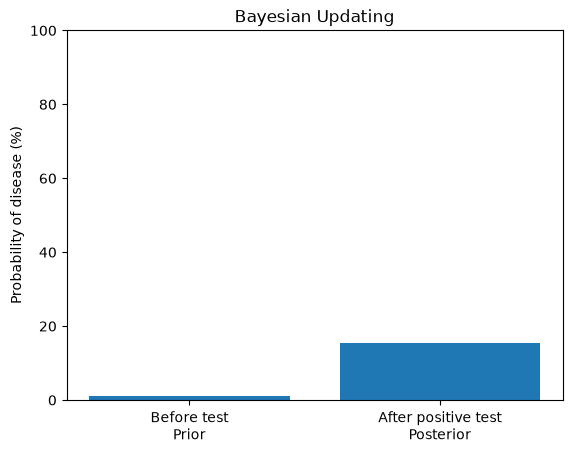

In [21]:
prior = p_disease * 100
posterior = p_disease_given_positive * 100

plt.bar(["Before test\nPrior", "After positive test\nPosterior"],
        [prior, posterior])

plt.ylabel("Probability of disease (%)")
plt.title("Bayesian Updating")
plt.ylim(0, 100)
plt.show()

# Part 9 — Understanding the medical example using 1,000 people

Counts often make Bayes' Rule easier to understand.

Imagine 1,000 people.

In [22]:
population = 1000

disease = population * 0.01
healthy = population - disease

true_positive = disease * 0.90
false_positive = healthy * 0.05

print("People with disease:", disease)
print("Healthy people:", healthy)
print("True positives:", true_positive)
print("False positives:", false_positive)

People with disease: 10.0
Healthy people: 990.0
True positives: 9.0
False positives: 49.5


### Graph 8 — Where do positive results come from?

Even though the test performs well, there are many more healthy people than diseased people. Therefore false positives matter.

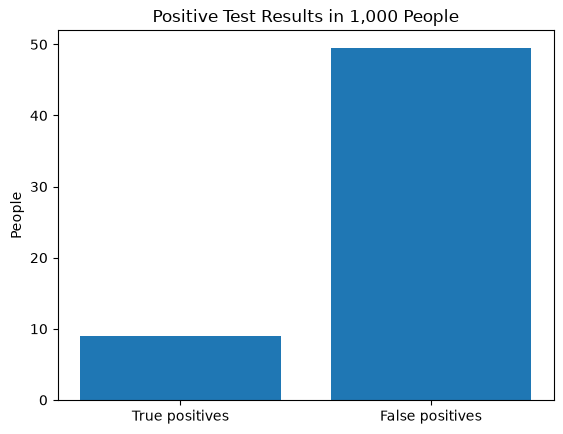

In [23]:
plt.bar(["True positives", "False positives"],
        [true_positive, false_positive])

plt.ylabel("People")
plt.title("Positive Test Results in 1,000 People")
plt.show()

The probability that a positive result represents actual disease is:

In [24]:
probability = true_positive / (true_positive + false_positive)

print("Probability =", probability)
print("Percentage =", round(probability * 100, 2), "%")

Probability = 0.15384615384615385
Percentage = 15.38 %


# Part 10 — How does disease prevalence affect the posterior?

This is a very important Bayesian idea.

We keep the test characteristics the same but change the **prior probability** of disease.

In [25]:
prevalences = np.arange(0.01, 0.51, 0.01)
posteriors = []

for p_disease in prevalences:

    p_no_disease = 1 - p_disease

    p_positive = (
        0.90 * p_disease
        +
        0.05 * p_no_disease
    )

    posterior = (0.90 * p_disease) / p_positive

    posteriors.append(posterior)

### Graph 9 — Prior probability changes the posterior

The same positive test result can mean something very different depending on the prior probability.

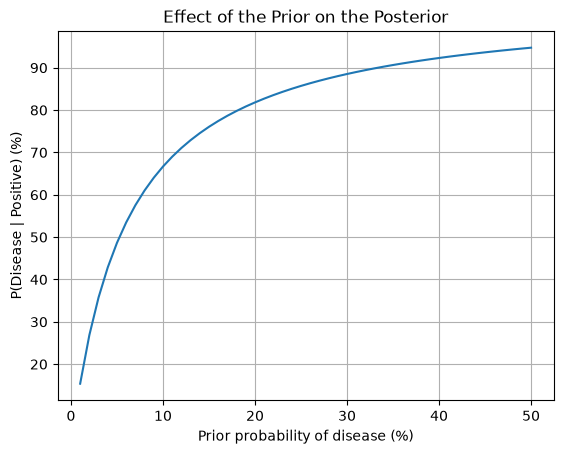

In [26]:
plt.plot(prevalences * 100, np.array(posteriors) * 100)
plt.xlabel("Prior probability of disease (%)")
plt.ylabel("P(Disease | Positive) (%)")
plt.title("Effect of the Prior on the Posterior")
plt.grid(True)
plt.show()

# Part 11 — Bayes in AI: Spam detection

Now let us apply exactly the same reasoning to an AI problem.

Suppose:

- P(Spam) = 0.20
- P(FREE | Spam) = 0.70
- P(FREE | Not Spam) = 0.10

An email contains the word **FREE**.

What is the probability that it is spam?

In [27]:
p_spam = 0.20
p_not_spam = 1 - p_spam

p_free_given_spam = 0.70
p_free_given_not_spam = 0.10

p_free = (
    p_free_given_spam * p_spam
    +
    p_free_given_not_spam * p_not_spam
)

p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print("P(FREE) =", p_free)
print("P(Spam | FREE) =", p_spam_given_free)
print("Spam probability =", round(p_spam_given_free * 100, 2), "%")

P(FREE) = 0.22
P(Spam | FREE) = 0.6363636363636362
Spam probability = 63.64 %


### Graph 10 — Spam probability before and after evidence

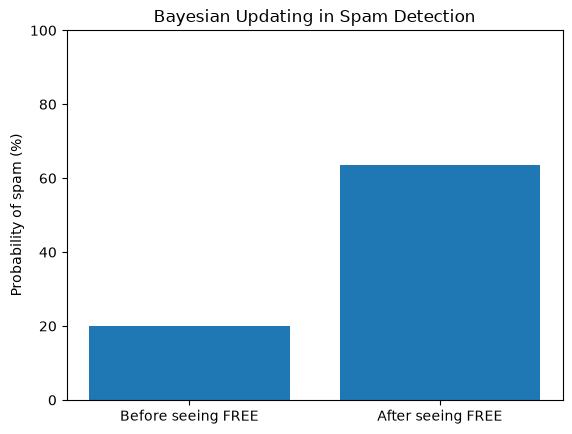

In [28]:
plt.bar(["Before seeing FREE", "After seeing FREE"],
        [p_spam * 100, p_spam_given_free * 100])

plt.ylabel("Probability of spam (%)")
plt.title("Bayesian Updating in Spam Detection")
plt.ylim(0, 100)
plt.show()

## Turn the posterior into an AI decision

In [29]:
spam_probability = p_spam_given_free

if spam_probability > 0.5:
    decision = "Spam"
else:
    decision = "Not Spam"

print("Probability:", round(spam_probability * 100, 2), "%")
print("AI classification:", decision)

Probability: 63.64 %
AI classification: Spam


# Part 12 — Student experiment: change the prior probability of spam

What if spam is rare?

Try P(Spam) = 0.05 while keeping the likelihoods unchanged.

In [30]:
p_spam = 0.05
p_not_spam = 1 - p_spam

p_free_given_spam = 0.70
p_free_given_not_spam = 0.10

p_free = (
    p_free_given_spam * p_spam
    +
    p_free_given_not_spam * p_not_spam
)

p_spam_given_free = (
    p_free_given_spam * p_spam
) / p_free

print("P(Spam | FREE) =", round(p_spam_given_free, 4))
print("Percentage =", round(p_spam_given_free * 100, 2), "%")

P(Spam | FREE) = 0.2692
Percentage = 26.92 %


# Part 13 — Weather example: evidence changes belief

Suppose:

- P(Rain) = 0.30
- P(Cloudy | Rain) = 0.80
- P(Cloudy | No Rain) = 0.20

You look outside and observe that it is cloudy.

What is:

**P(Rain | Cloudy)?**

In [31]:
p_rain = 0.30
p_no_rain = 1 - p_rain

p_cloudy_given_rain = 0.80
p_cloudy_given_no_rain = 0.20

p_cloudy = (
    p_cloudy_given_rain * p_rain
    +
    p_cloudy_given_no_rain * p_no_rain
)

p_rain_given_cloudy = (
    p_cloudy_given_rain * p_rain
) / p_cloudy

print("P(Cloudy) =", p_cloudy)
print("P(Rain | Cloudy) =", p_rain_given_cloudy)
print("Probability of rain =", round(p_rain_given_cloudy * 100, 2), "%")

P(Cloudy) = 0.38
P(Rain | Cloudy) = 0.631578947368421
Probability of rain = 63.16 %


### Graph 11 — Weather belief update

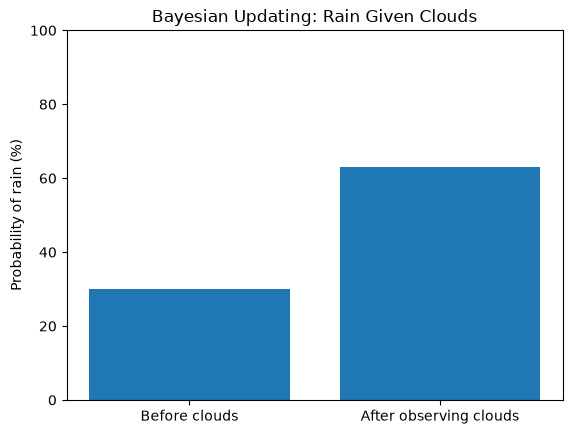

In [32]:
plt.bar(["Before clouds", "After observing clouds"],
        [p_rain * 100, p_rain_given_cloudy * 100])

plt.ylabel("Probability of rain (%)")
plt.title("Bayesian Updating: Rain Given Clouds")
plt.ylim(0, 100)
plt.show()

# Part 14 — A simple Bayesian agent

Now we connect Bayes' Rule with the intelligent-agent concept from W01.

The agent:

1. Has a prior belief about rain.
2. Observes evidence: the sky is cloudy.
3. Uses Bayes' Rule to update its belief.
4. Takes an action.

In [33]:
# Prior knowledge
p_rain = 0.30
p_no_rain = 0.70

# Knowledge about the evidence
p_cloudy_given_rain = 0.80
p_cloudy_given_no_rain = 0.20

# Sensor observation
cloudy = True

if cloudy:

    p_cloudy = (
        p_cloudy_given_rain * p_rain
        +
        p_cloudy_given_no_rain * p_no_rain
    )

    probability_rain = (
        p_cloudy_given_rain * p_rain
    ) / p_cloudy

else:
    probability_rain = p_rain

print("Probability of rain:",
      round(probability_rain * 100, 2), "%")

Probability of rain: 63.16 %


## Agent action

The agent now converts its belief into a decision.

In [34]:
if probability_rain > 0.5:
    action = "Take an umbrella"
else:
    action = "No umbrella needed"

print("Agent decision:", action)

Agent decision: Take an umbrella


# Part 15 — Decision threshold matters

An AI system does not necessarily have to use a threshold of 0.50.

For example, if getting wet is very costly, we may use a lower threshold for taking an umbrella.

In [35]:
probability_rain = 0.40

thresholds = [0.20, 0.30, 0.50, 0.70]

for threshold in thresholds:

    if probability_rain >= threshold:
        action = "Take umbrella"
    else:
        action = "No umbrella"

    print("Threshold:", threshold, "→", action)

Threshold: 0.2 → Take umbrella
Threshold: 0.3 → Take umbrella
Threshold: 0.5 → No umbrella
Threshold: 0.7 → No umbrella


### Graph 12 — Probability and decision thresholds

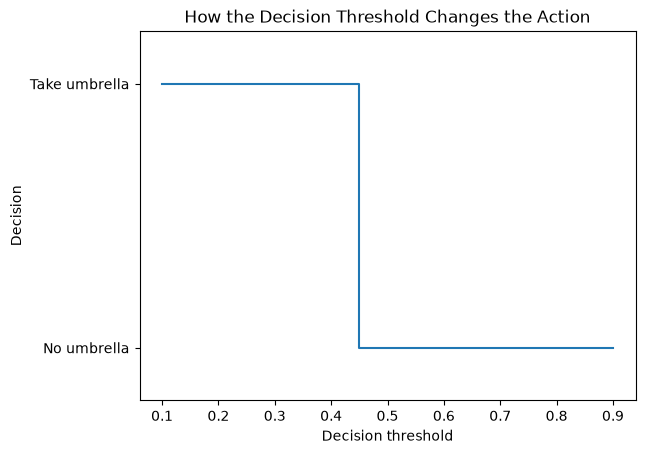

In [36]:
thresholds = np.arange(0.1, 1.0, 0.1)
decisions = []

for threshold in thresholds:
    if probability_rain >= threshold:
        decisions.append(1)
    else:
        decisions.append(0)

plt.step(thresholds, decisions, where="mid")
plt.xlabel("Decision threshold")
plt.ylabel("Decision")
plt.yticks([0, 1], ["No umbrella", "Take umbrella"])
plt.title("How the Decision Threshold Changes the Action")
plt.ylim(-0.2, 1.2)
plt.show()

# Part 16 — Student Exercise 1

An AI security system detects suspicious logins.

Suppose:

- P(Attack) = 0.10
- P(Alert | Attack) = 0.90
- P(Alert | No Attack) = 0.15

Calculate:

**P(Attack | Alert)**

Complete the missing lines.

In [37]:
p_attack = 0.10
p_no_attack = 0.90

p_alert_given_attack = 0.90
p_alert_given_no_attack = 0.15

# Step 1: calculate P(Alert)
p_alert = ???

# Step 2: calculate P(Attack | Alert)
p_attack_given_alert = ???

print("P(Attack | Alert) =", p_attack_given_alert)

SyntaxError: invalid syntax (275301060.py, line 8)

## Exercise 1 solution

Run this only after attempting the exercise.

In [ ]:
p_attack = 0.10
p_no_attack = 0.90

p_alert_given_attack = 0.90
p_alert_given_no_attack = 0.15

p_alert = (
    p_alert_given_attack * p_attack
    +
    p_alert_given_no_attack * p_no_attack
)

p_attack_given_alert = (
    p_alert_given_attack * p_attack
) / p_alert

print("P(Attack | Alert) =", round(p_attack_given_alert, 4))
print("Percentage =", round(p_attack_given_alert * 100, 2), "%")

# Part 17 — Student Exercise 2: visual comparison

Use the security example to plot:

- P(Attack) before the alert
- P(Attack | Alert) after the alert

Try to create the graph yourself before looking at previous examples.

# Part 18 — Challenge: compare different evidence strengths

For our weather agent, keep:

**P(Rain) = 0.30**

but change how strongly clouds indicate rain.

This graph shows how the posterior changes as `P(Cloudy | Rain)` becomes larger.

In [ ]:
p_rain = 0.30
p_no_rain = 0.70
p_cloudy_given_no_rain = 0.20

likelihoods = np.arange(0.20, 1.01, 0.05)
posterior_values = []

for likelihood in likelihoods:

    p_cloudy = (
        likelihood * p_rain
        +
        p_cloudy_given_no_rain * p_no_rain
    )

    posterior = (
        likelihood * p_rain
    ) / p_cloudy

    posterior_values.append(posterior)

plt.plot(likelihoods, posterior_values, marker="o")
plt.xlabel("P(Cloudy | Rain)")
plt.ylabel("P(Rain | Cloudy)")
plt.title("Effect of Evidence Strength on Bayesian Belief")
plt.grid(True)
plt.show()

# Part 19 — Summary

| Concept | Meaning | Example |
|---|---|---|
| **Uncertainty** | We do not know the outcome with certainty | Will it rain? |
| **Probability** | Numerical representation of uncertainty | P(Rain) = 0.30 |
| **Complement** | Probability that an event does not happen | P(No Rain) = 0.70 |
| **Joint probability** | Probability of events occurring together | P(Rain and Traffic) |
| **Conditional probability** | Probability given other information | P(Traffic \| Rain) |
| **Prior** | Belief before new evidence | P(Rain) = 0.30 |
| **Likelihood** | Probability of evidence if hypothesis is true | P(Cloudy \| Rain) |
| **Evidence** | New observation | Cloudy sky |
| **Posterior** | Updated probability after evidence | P(Rain \| Cloudy) |
| **Decision** | Action based on the probability | Take an umbrella |

## Key message

**AI often operates without certainty. Probability allows uncertainty to be represented, and Bayes' Rule allows an intelligent system to update its belief when new evidence becomes available.**

### Connection to W01

W01 introduced intelligent agents:

**Perceive → Decide → Act**

W02 adds probabilistic reasoning:

**Perceive evidence → Update belief → Decide → Act**

# Part 20 — Reflection questions

1. Why does a 90% sensitive medical test not necessarily mean that a person with a positive result has a 90% probability of disease?
2. What is the difference between a prior and a posterior probability?
3. Why can the same evidence produce different posterior probabilities for different priors?
4. In the spam example, what happens if the word FREE becomes common in legitimate email?
5. Why might an AI agent use a decision threshold other than 0.50?
6. Give one AI application where Bayesian updating could be useful.